In [85]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import date
import numpy as np
import datetime

pd.options.display.max_rows = 999
pd.options.display.max_columns = 999

In [86]:
df_k9 = pd.read_csv("../H3K9me3-zhuojie-regions/data/zhuojie_c1_avglogfc.csv")
df_k9 = df_k9.rename(columns={"avg_logFC": "logFC_k9"})
df_k9.shape

(91, 5)

In [87]:
df_k9.head(1)

,tissue,cell_type,logFC_k9,num_up_peaks,num_down_peaks
0,brainCB,brainCB-GC_ExN,-1.565036,2,273


In [88]:
files = [
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/BAT-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/brainCB-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/brainFC-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/brainHip-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/colon-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/heart-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/kidney-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/liver-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/lung-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/muscle-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/spleen-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
    "/storage/zhangyanxiaoLab/qihongjian/projects/paired_seq_tag/results/testis-merged/rna-qc/gene_edgeR_27M_over_3M.csv",
]

dfs = []
for f in files:
    tissue = f.split("-merged")[0].split("/")[-1]
    df = pd.read_csv(f)
    df["tissue"] = tissue
    cols = ['gene', 'logFC', 'logCPM', 'LR', 'PValue', 'FDR', 'cell_type', 'tissue']
    dfs.append(df[cols])

df_genes = pd.concat(dfs, ignore_index=True)
df_genes["cell_type"] = df_genes["tissue"] + '-' + df_genes["cell_type"]

df_genes = df_genes[df_genes["cell_type"].isin(df_k9["cell_type"].unique())]
df_genes.shape

(1013289, 8)

In [90]:
#df_genes.sample(1000).to_csv("df_genes.csv", index=False)

In [91]:
df_genes[df_genes["gene"]=="Stat5a"].head()

,gene,logFC,logCPM,LR,PValue,FDR,cell_type,tissue
9541,Stat5a,0.046820,4.918971,0.081304,0.775538,0.904187,BAT-ASPC,BAT
22873,Stat5a,0.055356,6.901949,0.078826,0.778895,0.898985,BAT-Adipocyte,BAT
41558,Stat5a,-0.276978,6.912876,1.373958,0.241133,0.464340,BAT-Brown_adipocyte,BAT
60871,Stat5a,0.053270,5.645545,0.091750,0.761964,0.923974,BAT-Myeloid_cell,BAT
84911,Stat5a,0.557890,4.708741,6.061286,0.013818,0.081092,BAT-Skeletal_muscle_cell,BAT


In [92]:
# df_genes.to_csv("data/gene_logFC.csv", index=False)

In [93]:
df_genes.shape
df_genes["tissue"].value_counts()

tissue
brainFC     191999
testis      118546
brainHip    117099
lung         98780
kidney       88652
heart        84842
BAT          72022
brainCB      69476
muscle       56476
liver        50002
colon        35141
spleen       30254
Name: count, dtype: int64

In [102]:

df_m

,gene,logFC,logCPM,LR,PValue,FDR,cell_type,tissue,logFC_k9,num_up_peaks,num_down_peaks
0,NaN,0.000000,NaN,NaN,NaN,NaN,BAT-ASPC,BAT,-0.609428,0,193
1,0610005C13Rik,-0.477494,4.234647,3.360628,0.066773,0.246002,BAT-Adipocyte,BAT,0.019454,50,17
2,0610005C13Rik,-0.438775,2.151250,1.406556,0.235629,0.457774,BAT-Brown_adipocyte,BAT,-0.275777,21,173
3,NaN,0.000000,NaN,NaN,NaN,NaN,BAT-Myeloid_cell,BAT,0.062297,2,0
4,0610005C13Rik,0.546574,3.500060,5.138401,0.023402,0.117416,BAT-Skeletal_muscle_cell,BAT,-0.150516,0,59
5,NaN,0.000000,NaN,NaN,NaN,NaN,BAT-Vascular_endothelial_cell,BAT,-0.401603,1,134
6,NaN,0.000000,NaN,NaN,NaN,NaN,brainCB-Asc_Glia,brainCB,-0.695036,3,202
7,NaN,0.000000,NaN,NaN,NaN,NaN,brainCB-BG_Glia,brainCB,-0.145055,7,12
8,0610005C13Rik,-0.196448,2.316546,1.246337,0.264253,0.517172,brainCB-GC_ExN,brainCB,-1.565036,2,273
9,NaN,0.000000,NaN,NaN,NaN,NaN,brainCB-MLI1_InN,brainCB,-0.448104,11,158


In [104]:
results = []

for gene, df_g in df_genes.groupby("gene"):
    df_m = (
        df_g
        .merge(df_k9, on=["tissue", "cell_type"], how="outer")
    )

    # missing logFC due to low expression, fill with NA
    df_m["logFC"] = df_m["logFC"].fillna(0)

    # 至少需要 10 个点
    if df_m.shape[0] < 10:
        continue

    # Pearson
    r_p, p_p = pearsonr(df_m["logFC"], df_m["logFC_k9"])

    # Spearman
    r_s, p_s = spearmanr(df_m["logFC"], df_m["logFC_k9"])

    results.append({
        "gene": gene,
        "n_points": df_m.shape[0],
        "pearson_r": r_p,
        "pearson_p": p_p,
        "spearman_r": r_s,
        "spearman_p": p_s
    })


In [105]:

df_corr = pd.DataFrame(results)
df_corr["pearson_fdr"] = multipletests(df_corr["pearson_p"],  method="fdr_bh")[1]
df_corr["spearman_fdr"] = multipletests(df_corr["spearman_p"],  method="fdr_bh")[1]
df_corr = df_corr.sort_values("pearson_fdr")
df_corr.to_csv("data/H3K9me3_gene_logFC_corr.csv", index=False)
df_corr.shape

(26356, 8)

In [107]:
df_corr[df_corr["gene"]=="H2-Q5"].head()

,gene,n_points,pearson_r,pearson_p,spearman_r,spearman_p,pearson_fdr,spearman_fdr
14798,H2-Q5,91,-0.343696,0.000851,-0.275154,0.008299,0.089141,0.232288


#### plot #####

In [74]:
pos_corr_f = df_corr[(df_corr['spearman_r'] > 0) & (df_corr['spearman_fdr'] < 0.05)]
neg_corr_f = df_corr[(df_corr['spearman_r'] < 0) & (df_corr['spearman_fdr'] < 0.05)]

# Order genes by spearman_fdr ascending (most significant first)
pos_genes_ordered = pos_corr_f.sort_values('spearman_fdr', ascending=True)['gene'].tolist()
neg_genes_ordered = neg_corr_f.sort_values('spearman_fdr', ascending=True)['gene'].tolist()

# Cell type order: low → high logFC_k9
ct_order = df_k9.sort_values('logFC_k9', ascending=True)['cell_type'].tolist()
logfc_k9_vals = df_k9.set_index('cell_type').loc[ct_order, 'logFC_k9'].values

# Build wide matrices
df_pos_wide = df_genes[df_genes['gene'].isin(pos_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='logFC', aggfunc='mean'
).reindex(index=pos_genes_ordered, columns=ct_order)

df_neg_wide = df_genes[df_genes['gene'].isin(neg_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='logFC', aggfunc='mean'
).reindex(index=neg_genes_ordered, columns=ct_order)

df_pos_sig = df_genes[df_genes['gene'].isin(pos_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='FDR', aggfunc='mean'
).reindex(index=pos_genes_ordered, columns=ct_order)

df_neg_sig = df_genes[df_genes['gene'].isin(neg_genes_ordered)].pivot_table(
    index='gene', columns='cell_type', values='FDR', aggfunc='mean'
).reindex(index=neg_genes_ordered, columns=ct_order)

print(f"Pos: {len(pos_genes_ordered)} genes | Neg: {len(neg_genes_ordered)} genes")
print(f"Top 5 pos genes by FDR: {pos_genes_ordered[:5]}")
print(f"Top 5 neg genes by FDR: {neg_genes_ordered[:5]}")


Pos: 86 genes | Neg: 100 genes
Top 5 pos genes by FDR: ['Ncapg2', 'Gpatch2', 'Exoc7', 'Slc4a3', 'Morn1']
Top 5 neg genes by FDR: ['Ppm1e', 'Cyp1b1', 'Rtn1', 'Tra2a', 'Grik2']


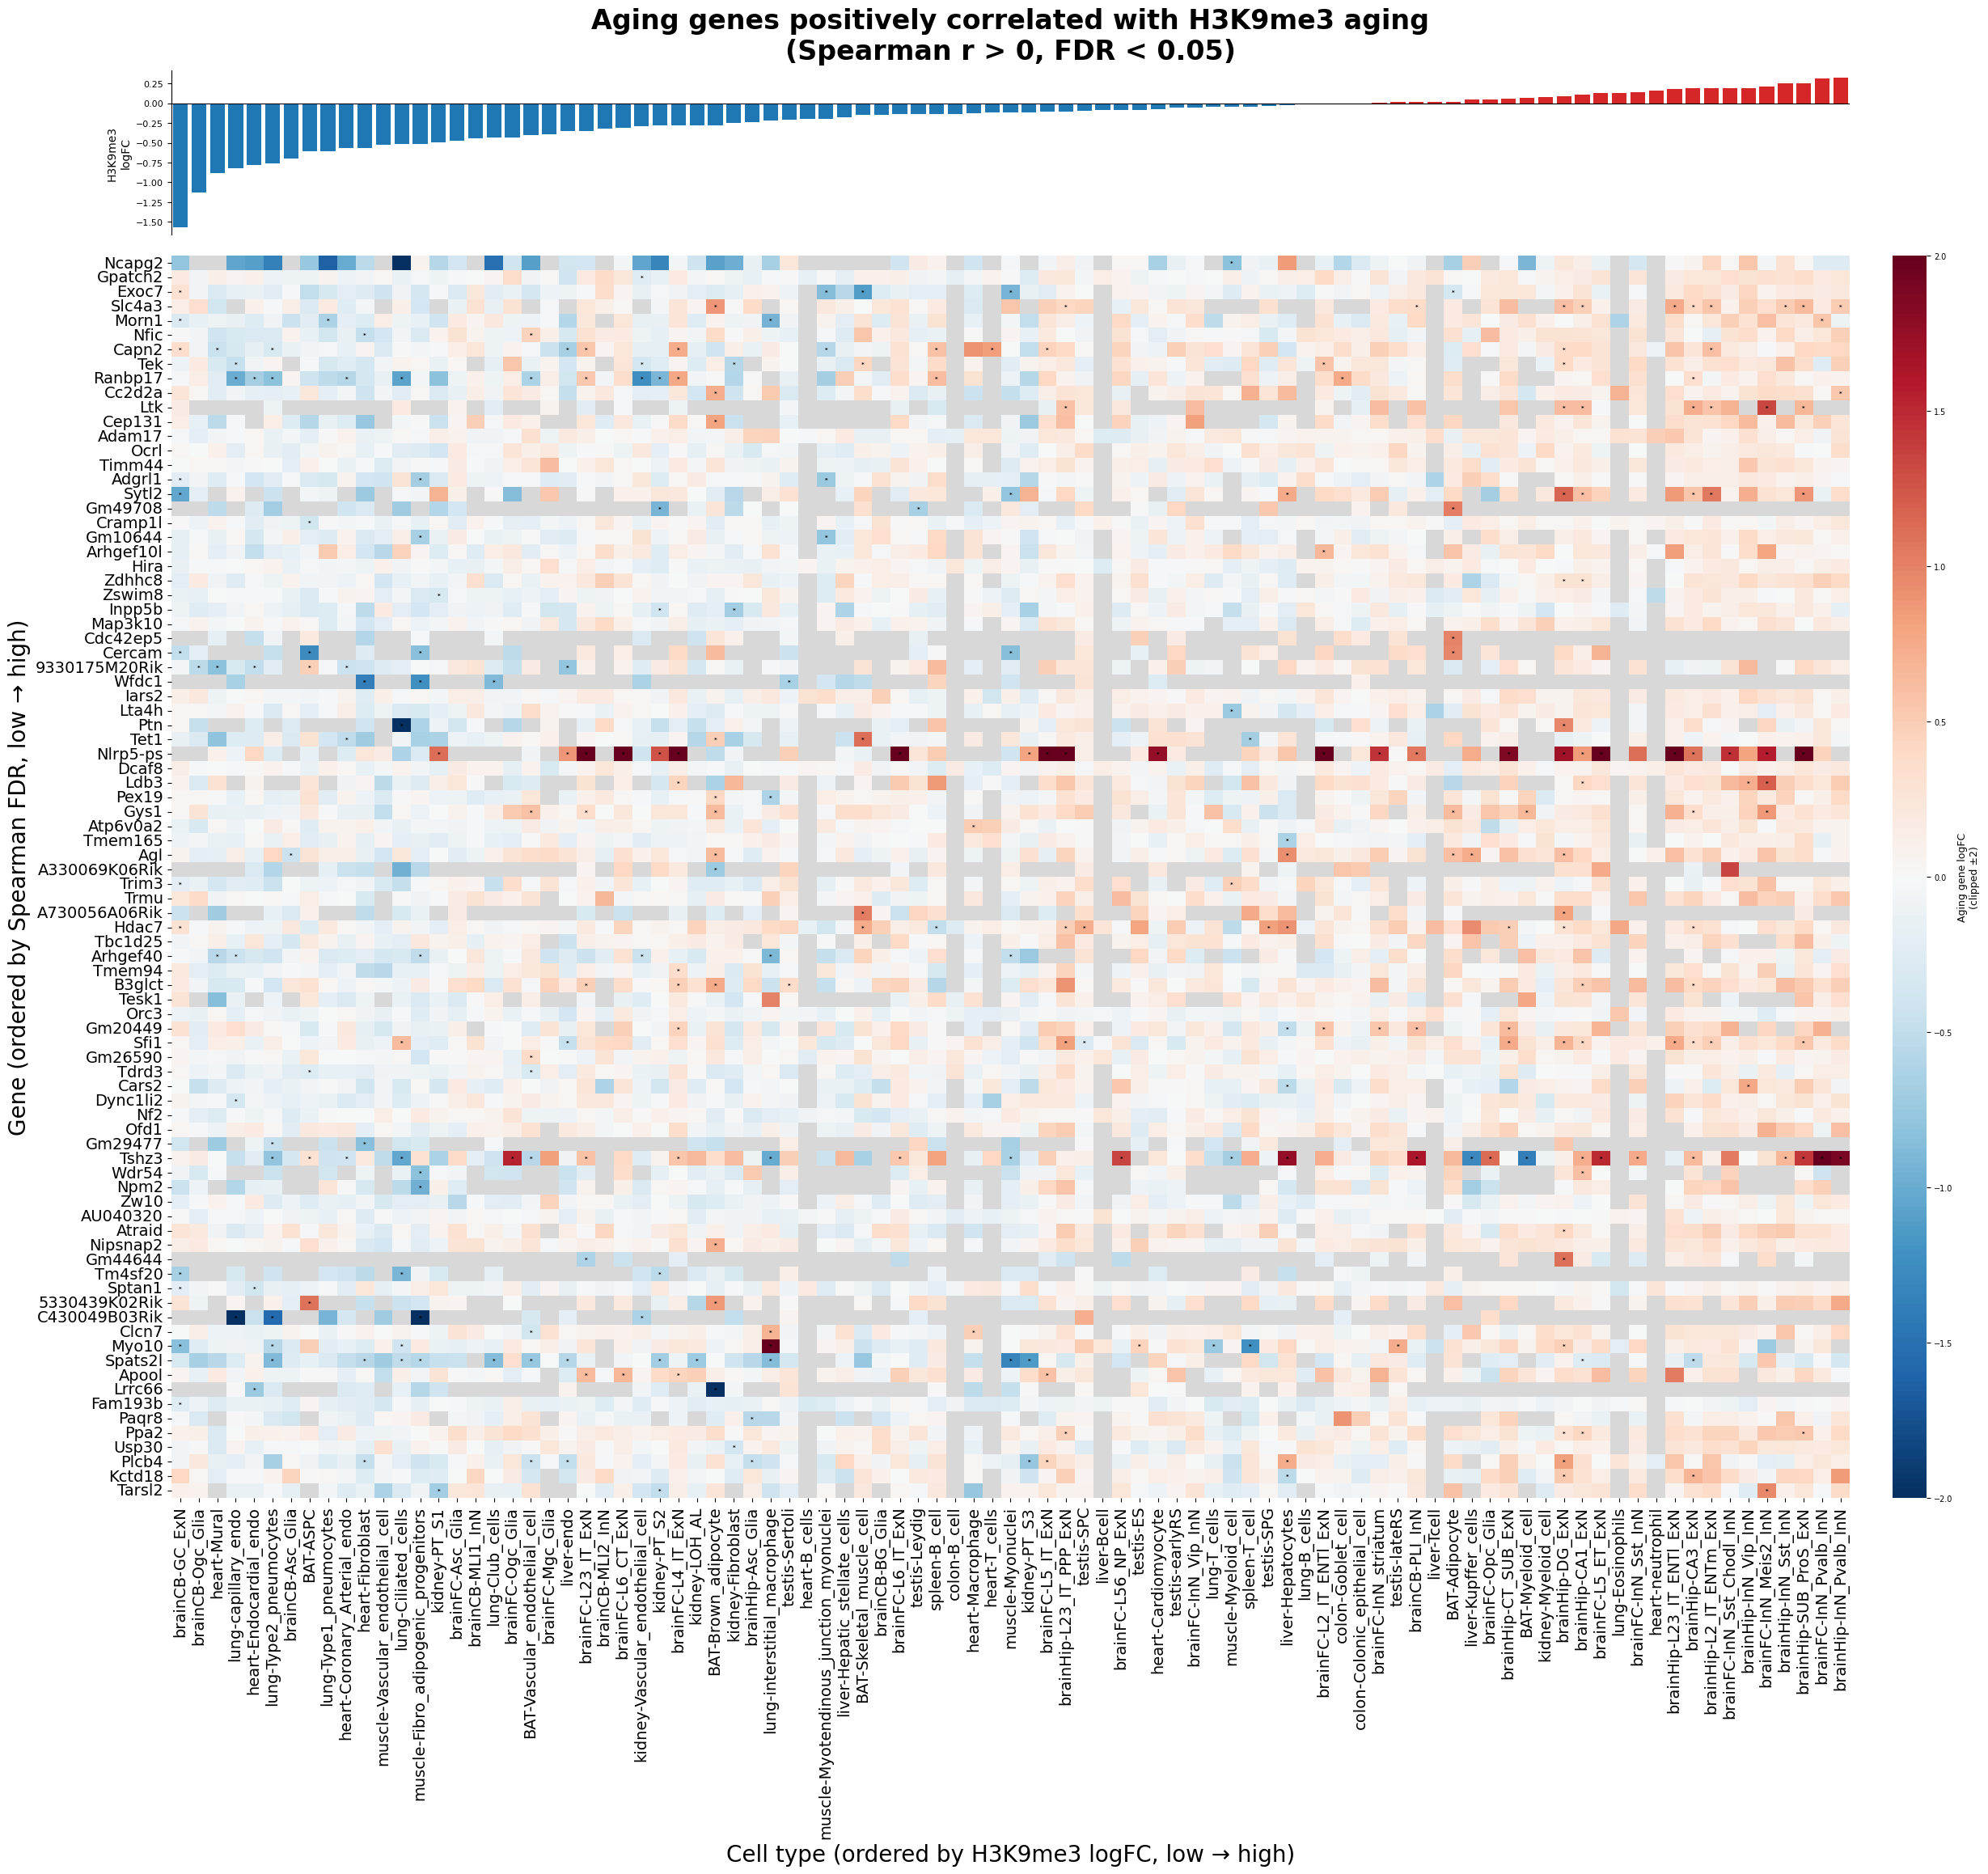

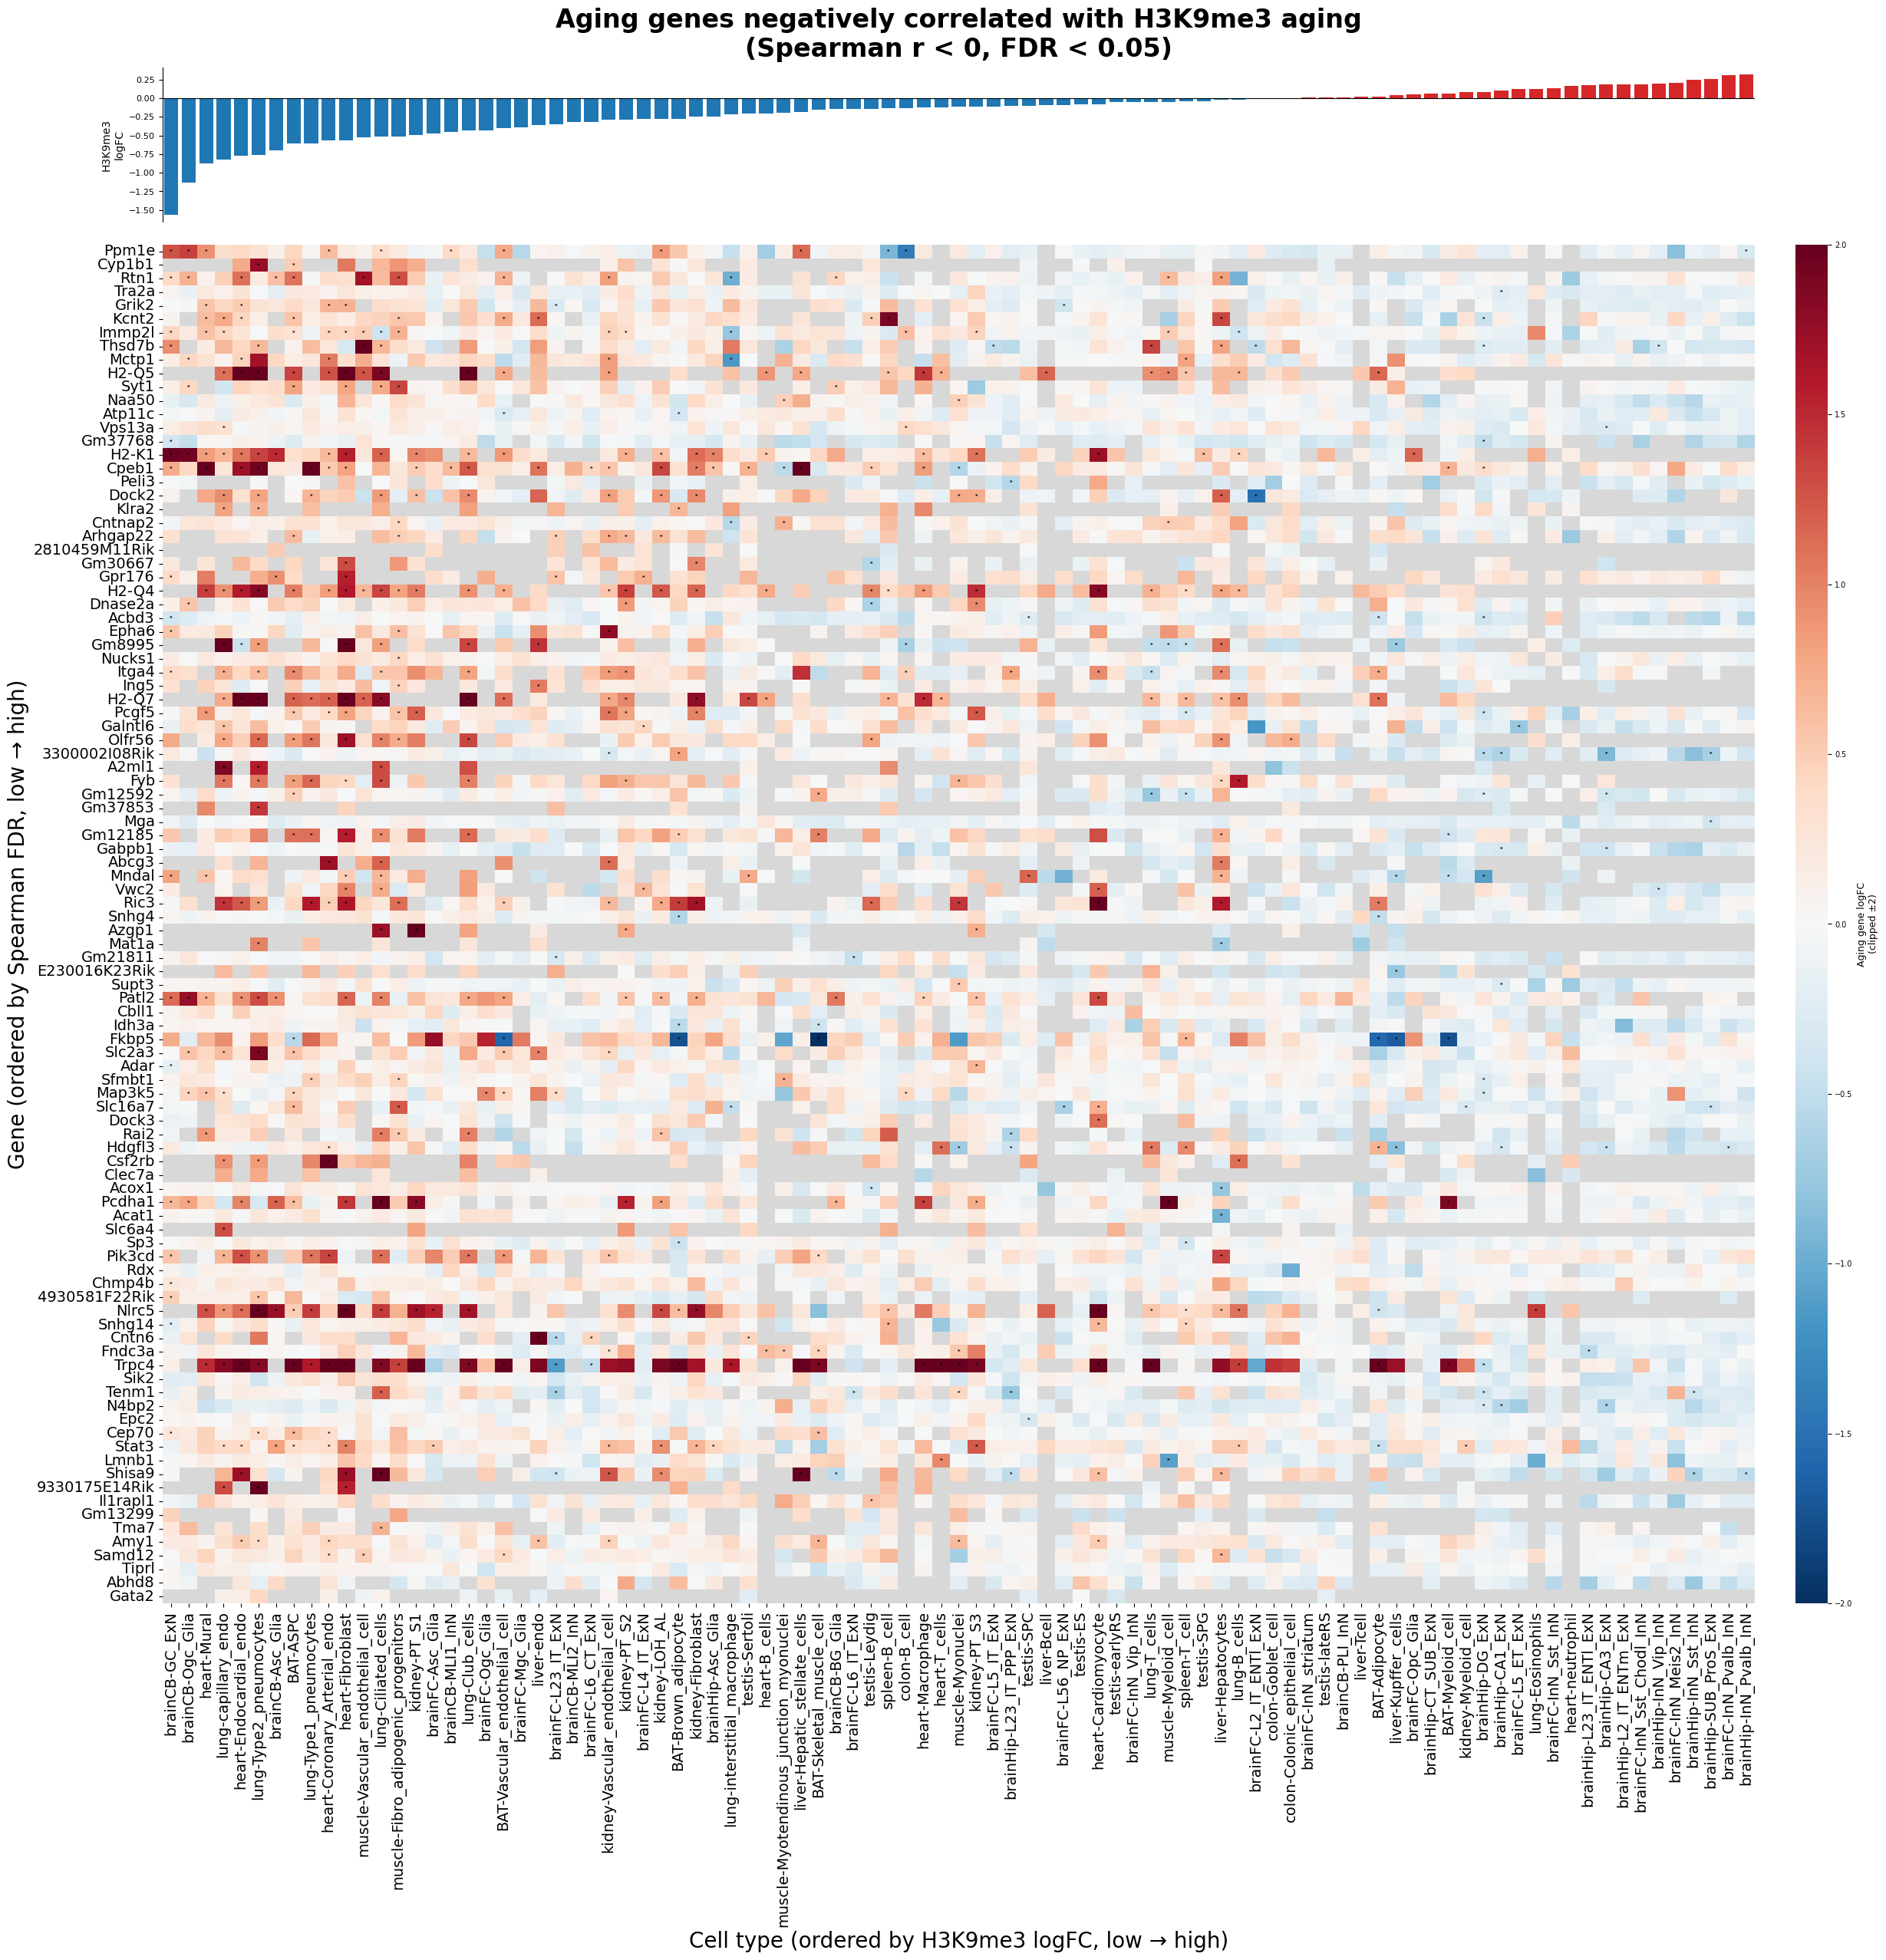

In [81]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

vmax = 2.0
bar_colors = ['#D62728' if v > 0 else '#1F77B4' for v in logfc_k9_vals]

def make_full_figure(wide_df, sig_df, genes_ordered, ct_order, logfc_k9_vals,
                     bar_colors, title, ylabel, row_height=0.22, star_fontsize=5):

    n_genes = len(genes_ordered)
    n_ct = len(ct_order)
    fig_height = max(10, n_genes * row_height + 4)

    fig = plt.figure(figsize=(28, fig_height))

    # ✅ 关键：2列 layout，右边给 colorbar
    gs = gridspec.GridSpec(
        2, 2,
        height_ratios=[2.5, n_genes * row_height],
        width_ratios=[50, 1],
        hspace=0.03,
        wspace=0.05
    )

    # ======================
    # 🔵 Bar plot（左上）
    # ======================
    ax_bar = fig.add_subplot(gs[0, 0])

    ax_bar.bar(range(n_ct), logfc_k9_vals,
               color=bar_colors, width=0.8, linewidth=0)

    ax_bar.axhline(0, color='black', linewidth=0.8)
    ax_bar.set_xlim(-0.5, n_ct - 0.5)

    ax_bar.set_xticks([])
    ax_bar.set_ylabel('H3K9me3\nlogFC', fontsize=10)
    ax_bar.tick_params(axis='y', labelsize=8)

    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.spines['bottom'].set_visible(False)

    ax_bar.set_title(title, fontsize=24, fontweight='bold', pad=10)

    # ======================
    # 🔴 Heatmap（左下）
    # ======================
    ax_heat = fig.add_subplot(gs[1, 0])

    # colorbar 单独轴
    cbar_ax = fig.add_subplot(gs[1, 1])

    mask = wide_df.isna()

    hm = sns.heatmap(
        wide_df.clip(-vmax, vmax),
        mask=mask,
        cmap='RdBu_r',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        ax=ax_heat,
        linewidths=0,
        cbar=True,
        cbar_ax=cbar_ax,   # ✅ 关键
        xticklabels=True,
        yticklabels=True,
    )

    ax_heat.set_facecolor('#D8D8D8')

    # ======================
    # ⭐ 标注显著性
    # ======================
    for i, gene in enumerate(genes_ordered):
        for j, ct in enumerate(ct_order):
            if ct not in sig_df.columns:
                continue

            fdr_val = sig_df.loc[gene, ct]

            if not np.isnan(fdr_val) and fdr_val < 0.05:
                ax_heat.text(
                    j + 0.5, i + 0.5, '*',
                    ha='center', va='center',
                    fontsize=star_fontsize,
                    color='black',
                    fontweight='bold'
                )

    # ======================
    # 🔧 axis 设置
    # ======================
    ax_heat.set_xlabel(
        'Cell type (ordered by H3K9me3 logFC, low → high)',
        fontsize=20
    )
    ax_heat.set_ylabel(ylabel, fontsize=20)

    ax_heat.tick_params(axis='x', labelsize=14, rotation=90)
    ax_heat.tick_params(axis='y', labelsize=14, rotation=0)

    # ======================
    # 🎯 colorbar 美化
    # ======================
    cbar = hm.collections[0].colorbar
    cbar.set_label('Aging gene logFC\n(clipped ±2)', fontsize=9)
    cbar.ax.tick_params(labelsize=7)

    return fig


# ======================
# 🚀 Figure 1: Positive
# ======================

fig1 = make_full_figure(
    df_pos_wide,
    df_pos_sig,
    pos_genes_ordered,
    ct_order,
    logfc_k9_vals,
    bar_colors,
    title='Aging genes positively correlated with H3K9me3 aging\n(Spearman r > 0, FDR < 0.05)',
    ylabel='Gene (ordered by Spearman FDR, low → high)',
)

fig1.show()


# ======================
# 🚀 Figure 2: Negative
# ======================

fig2 = make_full_figure(
    df_neg_wide,
    df_neg_sig,
    neg_genes_ordered,
    ct_order,
    logfc_k9_vals,
    bar_colors,
    title='Aging genes negatively correlated with H3K9me3 aging\n(Spearman r < 0, FDR < 0.05)',
    ylabel='Gene (ordered by Spearman FDR, low → high)',
)

fig2.show()